# 02 — Supervised Baseline (ISIC 2018)

Minimal baseline notebook: train once, reuse saved weights if they already exist, then print report-ready metrics and figures. Training logic lives in `src/trainers/supervised.py`.

In [1]:
import os
import sys
from pathlib import Path

# Keep project root on sys.path so `src` imports work inside the notebook
root = Path.cwd()
if root.name == "notebooks":
    root = root.parent
os.chdir(root)
sys.path.insert(0, str(root))

from src.datasets import build_loaders
from src.models import build_backbone
from src.reporting import evaluate_and_report, get_latest_run, plot_training_history, collect_auc_vs_fraction
from src.trainers.supervised import run_experiment
from src.utils import get_device, load_config
from src.metrics import plot_auc_vs_labels
from data.scripts.make_label_subsets import main as generate_subsets


## 1. Load config

In [2]:
config = load_config("configs/baseline.yaml")
config

{'experiment': {'name': 'baseline_resnet18_full',
  'seed': 42,
  'device': 'auto'},
 'data': {'task': 'supervised',
  'train_csv': 'data/processed/isic2018/train.csv',
  'val_csv': 'data/processed/isic2018/val.csv',
  'test_csv': 'data/processed/isic2018/test.csv',
  'img_size': 224,
  'batch_size': 64,
  'num_workers': 4,
  'use_weighted_sampler': True,
  'label_col': 'target'},
 'model': {'arch': 'resnet18', 'pretrained': True, 'num_classes': 1},
 'training': {'epochs': 50,
  'optimizer': 'adamw',
  'lr_backbone': 0.0001,
  'lr_head': 0.001,
  'weight_decay': 0.0001,
  'scheduler': 'cosine',
  'freeze_backbone_epochs': 5},
 'loss': {'type': 'focal', 'gamma': 2.0, 'alpha': 0.75},
 'early_stopping': {'patience': 10, 'monitor': 'val_auc'},
 'logging': {'save_dir': 'results/runs', 'log_every': 10}}

## 2. Run baseline

Train once if needed. If a run already exists, the notebook reuses the saved checkpoint instead of retraining.

In [3]:
RUN_TRAINING = False   # set to True only to retrain

exp_name = config["experiment"]["name"]

if RUN_TRAINING:
    result = run_experiment(config)
    run_dir = Path(result["run_dir"])
else:
    run_dir = get_latest_run(exp_name)
    if run_dir is None:
        raise FileNotFoundError(
            f"No runs found for '{exp_name}' under results/runs. "
            "Set RUN_TRAINING = True to create a new run."
        )

print("Run dir:", run_dir)

Run dir: results/runs/baseline_resnet18_full/20260530_140056


## 3. Evaluate best checkpoint on test set

Print report-ready metrics and save confusion matrix, ROC curve, and training-history plot.

/opt/homebrew/Caskroom/miniconda/base/envs/isic-dl/lib/python3.11/site-packages/torch/utils/data/sampler.py:227: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /Users/runner/work/_temp/anaconda/conda-bld/pytorch_1711403251597/work/torch/csrc/utils/tensor_numpy.cpp:212.)
  weights_tensor = torch.as_tensor(weights, dtype=torch.double)



=== Test Set Evaluation ===
  AUC-ROC:            0.9181
  Balanced Accuracy:  0.8318
  Macro F1:           0.6670
  Precision (Malig):  0.3227
  Recall (Malig):     0.9018
  Confusion matrix:
[[678 212]
 [ 11 101]]

Artifacts saved to: results/runs/baseline_resnet18_full/20260530_140056


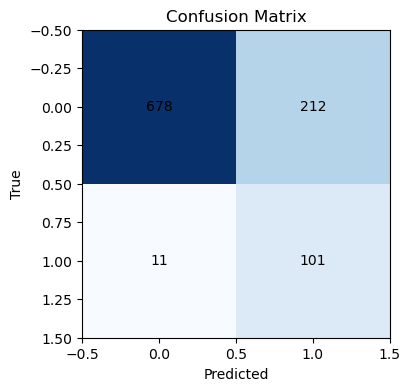

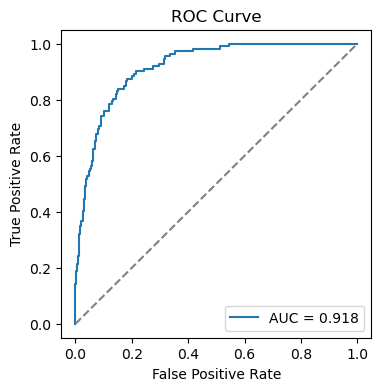

In [4]:
# Build test loader and model (model will be loaded inside evaluate_and_report)
loaders = build_loaders(config)
device = get_device(config["experiment"].get("device"))
model = build_backbone(
    arch=config["model"]["arch"],
    pretrained=config["model"].get("pretrained", True),
    num_classes=config["model"].get("num_classes", 1),
)

# Run evaluation: computes metrics, saves test_metrics.json, generates figures
metrics = evaluate_and_report(run_dir, model, loaders["test"], device)

In [5]:
plot_training_history(run_dir, save_path=str(run_dir / "figures" / "training_history.png"))

In [6]:
# Cell 11: Generate label subsets if they don't exist

subset_dir = Path("data/processed/isic2018/subsets")
subset_files_exist = subset_dir.exists() and any(subset_dir.glob("train_*.csv"))

if not subset_files_exist:
    print("Generating label subsets...")
    generate_subsets()   # runs the script's main logic
    print("Done.")
else:
    print("Label subsets already exist.")

Label subsets already exist.


In [7]:
# Cell 12 – Train label‑budget models and generate test metrics
from data.scripts.make_label_subsets import FRACTIONS 
import json

exp_name_prefix = "baseline_resnet18_{:.2f}"
base_config = config.copy()

for frac in FRACTIONS:
    exp_name = exp_name_prefix.format(frac)
    run_dir = get_latest_run(exp_name)
    
    # Check if run already has best checkpoint and test_metrics.json
    has_checkpoint = False
    has_test_metrics = False
    if run_dir is not None:
        ckpt_path = run_dir / "checkpoints/best.pt"
        metrics_path = run_dir / "test_metrics.json"
        has_checkpoint = ckpt_path.exists()
        has_test_metrics = metrics_path.exists()
    
    if has_checkpoint and has_test_metrics:
        print(f"Skipping {exp_name} (already complete)")
        continue
    
    # If checkpoint exists but no test metrics, just evaluate
    if has_checkpoint and not has_test_metrics:
        print(f"Found checkpoint for {exp_name}, evaluating on test set...")
        # Build test loader and model
        cfg = base_config.copy()
        cfg["data"] = base_config["data"].copy()
        pct = int(round(frac * 100))
        cfg["data"]["train_csv"] = f"data/processed/isic2018/subsets/train_{pct:02d}pct.csv"
        loaders = build_loaders(cfg)
        device = get_device(cfg["experiment"].get("device", "auto"))
        model = build_backbone(
            arch=cfg["model"]["arch"],
            pretrained=cfg["model"].get("pretrained", True),
            num_classes=cfg["model"].get("num_classes", 1),
        )
        # Run evaluation (this will create test_metrics.json and figures)
        evaluate_and_report(run_dir, model, loaders["test"], device)
        print(f"Evaluation done for {exp_name}")
        continue
    
    # Otherwise, train from scratch
    print(f"\nTraining {exp_name}...")
    cfg = base_config.copy()
    cfg["experiment"] = base_config["experiment"].copy()
    cfg["experiment"]["name"] = exp_name
    cfg["data"] = base_config["data"].copy()
    pct = int(round(frac * 100))
    cfg["data"]["train_csv"] = f"data/processed/isic2018/subsets/train_{pct:02d}pct.csv"
    
    # Train
    result = run_experiment(cfg)
    run_dir = Path(result["run_dir"])
    
    # Evaluate on test set
    loaders = build_loaders(cfg)
    device = get_device(cfg["experiment"].get("device", "auto"))
    model = build_backbone(
        arch=cfg["model"]["arch"],
        pretrained=cfg["model"].get("pretrained", True),
        num_classes=cfg["model"].get("num_classes", 1),
    )
    evaluate_and_report(run_dir, model, loaders["test"], device)
    print(f"Finished training and evaluation for {exp_name}")

Skipping baseline_resnet18_0.01 (already complete)
Skipping baseline_resnet18_0.05 (already complete)
Skipping baseline_resnet18_0.10 (already complete)
Skipping baseline_resnet18_0.25 (already complete)
Skipping baseline_resnet18_0.50 (already complete)


Added full baseline AUC: 0.9181

Final collected AUCs: {0.01: 0.8137841091492777, 0.05: 0.8629213483146068, 0.1: 0.8630517656500802, 0.25: 0.8678571428571429, 0.5: 0.9065208667736758, 1.0: 0.9181179775280899}


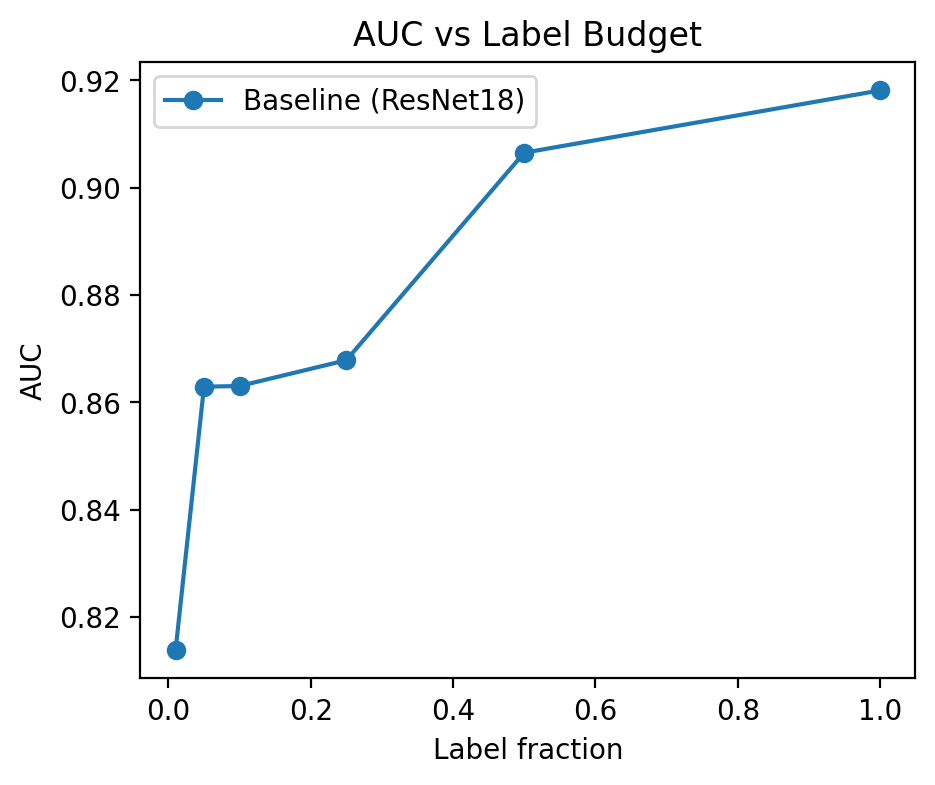

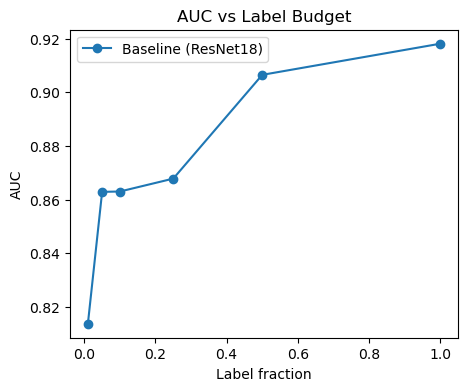

In [8]:
# Cell 13: Build AUC vs label fraction plot
import json
from data.scripts.make_label_subsets import FRACTIONS

# Collect AUCs for fraction runs (0.01 to 0.50)
aucs = collect_auc_vs_fraction(exp_name_prefix, FRACTIONS)

# Manually add the original full baseline run (100% labels)
full_run_dir = get_latest_run("baseline_resnet18_full")
if full_run_dir:
    metrics_path = full_run_dir / "test_metrics.json"
    if metrics_path.exists():
        with open(metrics_path) as f:
            data = json.load(f)
            aucs[1.00] = data.get("auc_roc")
            print(f"Added full baseline AUC: {aucs[1.00]:.4f}")
    else:
        print("Full baseline test_metrics.json not found")
else:
    print("Full baseline run not found")

# Filter out missing fractions
valid_aucs = {f: auc for f, auc in aucs.items() if auc is not None}
print("\nFinal collected AUCs:", valid_aucs)

if valid_aucs:
    figures_dir = Path("results/figures")
    figures_dir.mkdir(parents=True, exist_ok=True)
    save_path = figures_dir / "auc_vs_labels.png"
    
    plot_auc_vs_labels({"Baseline (ResNet18)": valid_aucs}, save_path=str(save_path))
    
    from IPython.display import Image
    display(Image(save_path))
else:
    print("No AUCs collected. Check that runs completed and test_metrics.json exists.")